In [1]:
pip install kaggle numpy pandas matplotlib seaborn scikit-learn tensorflow


   ---------------- ----------------------- 2/5 [python-slugify]
   ------------------------ --------------- 3/5 [bleach]
   ------------------------ --------------- 3/5 [bleach]
   -------------------------------- ------- 4/5 [kaggle]
   -------------------------------- ------- 4/5 [kaggle]
   -------------------------------- ------- 4/5 [kaggle]
   -------------------------------- ------- 4/5 [kaggle]
   ---------------------------------------- 5/5 [kaggle]

Note: you may need to restart the kernel to use updated packages.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout,
    Flatten, BatchNormalization
)
from tensorflow.keras.utils import to_categorical

In [2]:
import numpy as np
import pandas as pd

train_df = pd.read_csv("mitbih_train.csv", header=None, dtype=np.float32)
test_df = pd.read_csv("mitbih_test.csv", header=None, dtype=np.float32)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)


Train shape: (87554, 188)
Test shape: (21892, 188)


In [3]:
print("Train label distribution:")
print(train_df.iloc[:, 187].value_counts())

print("\nTest label distribution:")
print(test_df.iloc[:, 187].value_counts())


Train label distribution:
187
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64

Test label distribution:
187
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64


In [4]:
X_train = train_df.iloc[:, :187].values
y_train = train_df.iloc[:, 187].astype(int).values

X_test = test_df.iloc[:, :187].values
y_test = test_df.iloc[:, 187].astype(int).values


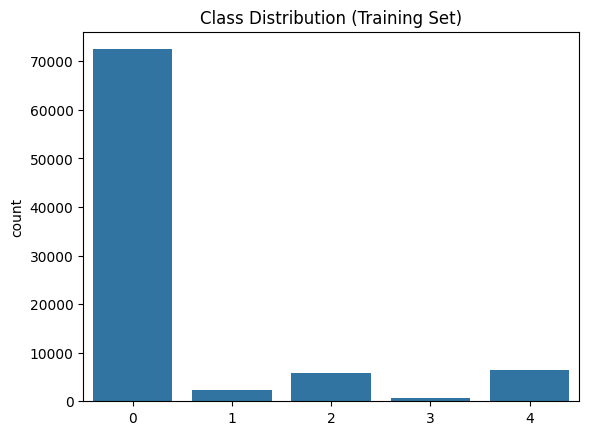

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=y_train)
plt.title("Class Distribution (Training Set)")
plt.show()

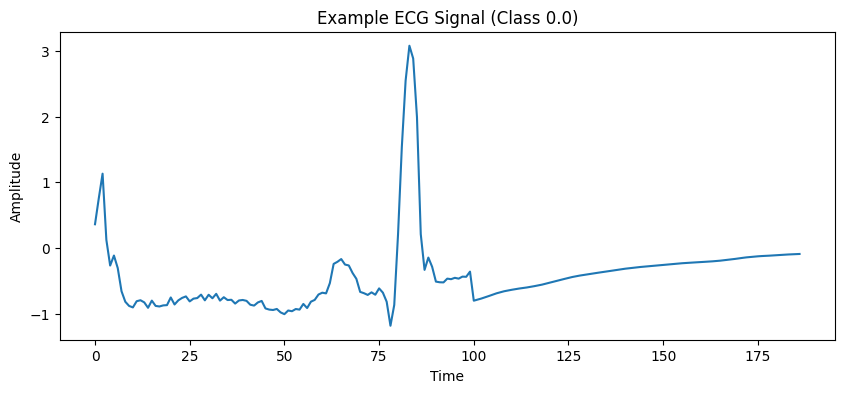

In [33]:
plt.figure(figsize=(10,4))
plt.plot(X_train[0])
plt.title(f"Example ECG Signal (Class {y_train[0]})")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

In [19]:
train_df = pd.read_csv("mitbih_train.csv", header=None)
test_df  = pd.read_csv("mitbih_test.csv", header=None)

# Separate features and labels
X_train = train_df.iloc[:, :-1].values
y_train = train_df.iloc[:, -1].values

X_test = test_df.iloc[:, :-1].values
y_test = test_df.iloc[:, -1].values

print("Train label distribution:", np.unique(y_train, return_counts=True))
print("Test label distribution:", np.unique(y_test, return_counts=True))

Train label distribution: (array([0., 1., 2., 3., 4.]), array([72471,  2223,  5788,   641,  6431], dtype=int64))
Test label distribution: (array([0., 1., 2., 3., 4.]), array([18118,   556,  1448,   162,  1608], dtype=int64))


In [20]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# CNN input shape: (samples, timesteps, channels)
X_train = X_train.reshape(-1, 187, 1)
X_test  = X_test.reshape(-1, 187, 1)

In [21]:
y_train_cat = to_categorical(y_train, num_classes=5)
y_test_cat  = to_categorical(y_test, num_classes=5)

In [22]:
classes = np.unique(y_train)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = dict(zip(classes, class_weights))
print("Class weights:", class_weight_dict)

Class weights: {0.0: 0.24162492583240192, 1.0: 7.877103013945119, 2.0: 3.0253628196268143, 3.0: 27.317940717628705, 4.0: 2.7228735810915876}


In [23]:
model = Sequential([
    Conv1D(32, kernel_size=5, activation='relu', input_shape=(187, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Conv1D(64, kernel_size=5, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(5, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

c:\Users\NamNguyenn\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 183, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 183, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 91, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 87, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 87, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 43, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2752)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       352,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 363,909 (1.39 MB)

 Trainable params: 363,717 (1.39 MB)

 Non-trainable params: 192 (768.00 B)

In [24]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    epochs=20,
    batch_size=128,
    class_weight=class_weight_dict,
    verbose=1
)

Epoch 1/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.7188 - loss: 0.6920 - val_accuracy: 0.8478 - val_loss: 0.4863
Epoch 2/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 15s 22ms/step - accuracy: 0.8102 - loss: 0.4219 - val_accuracy: 0.8733 - val_loss: 0.3563
Epoch 3/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.8333 - loss: 0.3543 - val_accuracy: 0.8449 - val_loss: 0.4026
Epoch 4/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 25s 36ms/step - accuracy: 0.8560 - loss: 0.3018 - val_accuracy: 0.8954 - val_loss: 0.3336
Epoch 5/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.8651 - loss: 0.2753 - val_accuracy: 0.8985 - val_loss: 0.2794
Epoch 6/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.8820 - loss: 0.2430 - val_accuracy: 0.9062 - val_loss: 0.2549
Epoch 7/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 26s 38ms/step - accuracy: 0.8851 - loss: 0.2322 - val_accuracy: 0.9220 - val_loss: 0.2156
Epoch 8/20
685/685 ━━━━━━━━━━━━━━━━━━━━ 42s 39ms/step - accuracy: 0.9030 - loss: 0.2010 - 

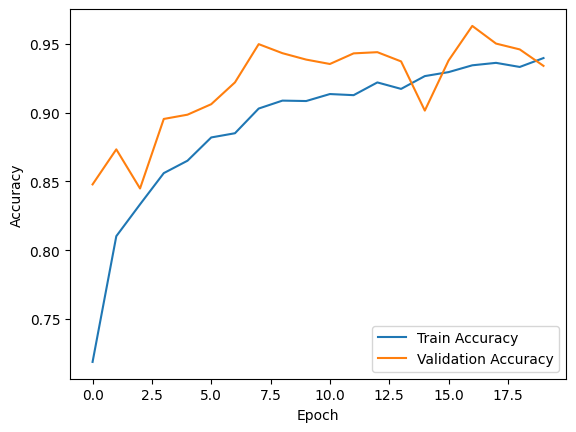

In [25]:
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [26]:
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_classes))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred_classes))

685/685 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      0.93      0.96     18118
         1.0       0.59      0.82      0.69       556
         2.0       0.77      0.94      0.84      1448
         3.0       0.22      0.92      0.36       162
         4.0       0.95      0.98      0.97      1608

    accuracy                           0.93     21892
   macro avg       0.70      0.92      0.76     21892
weighted avg       0.96      0.93      0.94     21892


Confusion Matrix:

[[16903   308   370   462    75]
 [   67   456    21     9     3]
 [   25     5  1359    57     2]
 [    6     0     7   149     0]
 [   11     4    12     0  1581]]
